In [19]:
import os
import numpy as np # numerical values
import pandas as pd # tables
import matplotlib.pyplot as plt # for plots
from pathlib import Path

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("The environment is ready: pandas", pd.__version__)

The environment is ready: pandas 3.0.3


In [20]:
df = pd.read_csv("data/yaleemmlc_admissionprediction_triage.csv")
print(f"Loaded {df.shape[0]:,} ED encounters x {df.shape[1]} columns")
df.head()

Loaded 55,121 ED encounters x 226 columns


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,...,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,Admit,Walk-in,September,Monday,11-14,Discharge,118.0,105.0,79.0,20.0,98.0,0.0,97.5,113.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,Discharge,ambulance,June,Tuesday,15-18,Admit,76.0,116.0,71.0,18.0,99.0,0.0,98.1,108.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,Discharge,Car,April,Sunday,23-02,Discharge,106.0,103.0,63.0,16.0,97.0,0.0,98.2,85.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,Discharge,ambulance,July,Wednesday,23-02,Discharge,84.0,109.0,68.0,18.0,95.0,0.0,97.8,88.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
# Data Groups and Schema 

# Global target variable definition
TARGET = "esi"

CLEAN_LABELS = {
    "esi": "Acuity (ESI)",
    "triage_vital_hr": "Heart Rate",
    "triage_vital_sbp": "Systolic BP",
    "triage_vital_dbp": "Diastolic BP",
    "triage_vital_rr": "Resp Rate",
    "triage_vital_o2": "Oxygen Sat (SpO2)",
    "triage_vital_o2_device": "Supplemental oxygen",
    "triage_vital_temp": "Temperature (°F)",
    "triage_vital_temp_c": "Temperature (°C)",
    "triage_glucose": "Blood Glucose"
}

# Vital signs measured during triage
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

# Patient demographics
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion", 
                "maritalstatus", "employstatus", "insurance_status"]

# Administrative details 
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]

# Post-triage features
LEAKAGE = ["disposition", "previousdispo"]
def classify_columns(df):
    """Sort the DataFrame columns into families and return them in a dictionary"""
    def keep_present(wanted):
        present = []
        for col in wanted:
            if col in df.columns:
                present.append(col)
        return present
    
    # grabs any columns starting with "cc_"
    chief_complaints = []
    for col in df.columns:
        if col.startswith("cc_"):
            chief_complaints.append(col)

    families = {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }
    return families

In [22]:
# Clinical Ranges Values
# Healthy Adult Ranges
NORMAL_RANGES = {
    "triage_vital_hr": (60, 100, "bpm"), 
    "triage_vital_sbp": (90, 140, "mmHg"),
    "triage_vital_dbp": (60, 90, "mmHg"), 
    "triage_vital_rr": (12, 20, "/min"),
    "triage_vital_o2": (95, 100, "%"), 
    "triage_vital_temp": (97.0, 99.5, "°F"), 
    "triage_vital_temp_c": (36.1, 37.5, "°C"), 
    "triage_glucose": (70, 140, "mg/dL")
}

# cutoffs for biologically possible values

PLAUSIBLE = {
    "age": (0, 120), "esi": (1, 5), 
    "triage_vital_hr": (20, 250), 
    "triage_vital_sbp": (50, 300),
    "triage_vital_dbp": (20, 200), 
    "triage_vital_rr": (4, 60), 
    "triage_vital_o2": (50, 100),
    "triage_vital_temp": (86, 110), 
    "triage_vital_temp_c": (30, 43.3), 
    "triage_glucose": (20, 800)
}
def clean_triage(raw):
    """Takes the raw DataFrame and returns a cleaned copy"""
    d = raw.copy()
    fam = classify_columns(d)

    # Drop rows missing the target variable
    d = d[d[TARGET].notna()].copy()

    # Force vital signs and age to numeric
    numeric_cols = list(fam["vitals"])
    if "age" in d.columns:
        numeric_cols.append("age")
    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")
    
    # Mask impossible values to NaN
    for col in PLAUSIBLE:
        low, high = PLAUSIBLE[col]
        if col in d.columns:
            out_of_range = (d[col] < low) | (d[col] > high)
            d.loc[out_of_range, col] = np.nan

    # Impute missing vitals with the median value
    for col in fam["vitals"]:
        d[col] = d[col].fillna(d[col].median())

    # Fill empty oxygen-device or chief-complaint flags with 0
    if "triage_vital_o2_device" in d.columns:
        d["triage_vital_o2_device"] = d["triage_vital_o2_device"].fillna(0)
    for col in fam["chief_complaints"]:
        d[col] = d[col].fillna(0)
        
    # Fill empty text fields with 'Unknown'
    for col in fam["demographics"] + fam["admin"] + fam["leakage"]:
        if d[col].dtype == object:
            d[col] = d[col].fillna("Unknown")

    # Round target labels to whole numbers
    d[TARGET] = d[TARGET].round().astype(int)
    return d

# Load inputs
CLEAN_PATH, RAW_PATH = Path("data/triage_cleaned_v1.csv"), Path("data/yaleemmlc_admissionprediction_triage.csv")
if CLEAN_PATH.exists():
    df = pd.read_csv(CLEAN_PATH)
    print("Loaded cleaned data")
elif RAW_PATH.exists():
    df = clean_triage(pd.read_csv(RAW_PATH, index_col=0))
    print("Rebuilt from raw via clean_triage()")
else:
    raise FileNotFoundError("Need triage_cleaned_v1.csv or raw files.")

raw = pd.read_csv(RAW_PATH, index_col=0) if RAW_PATH.exists() else None
fam = classify_columns(df)
os.makedirs("figs", exist_ok=True) #creates a folder to store graphs

Rebuilt from raw via clean_triage()


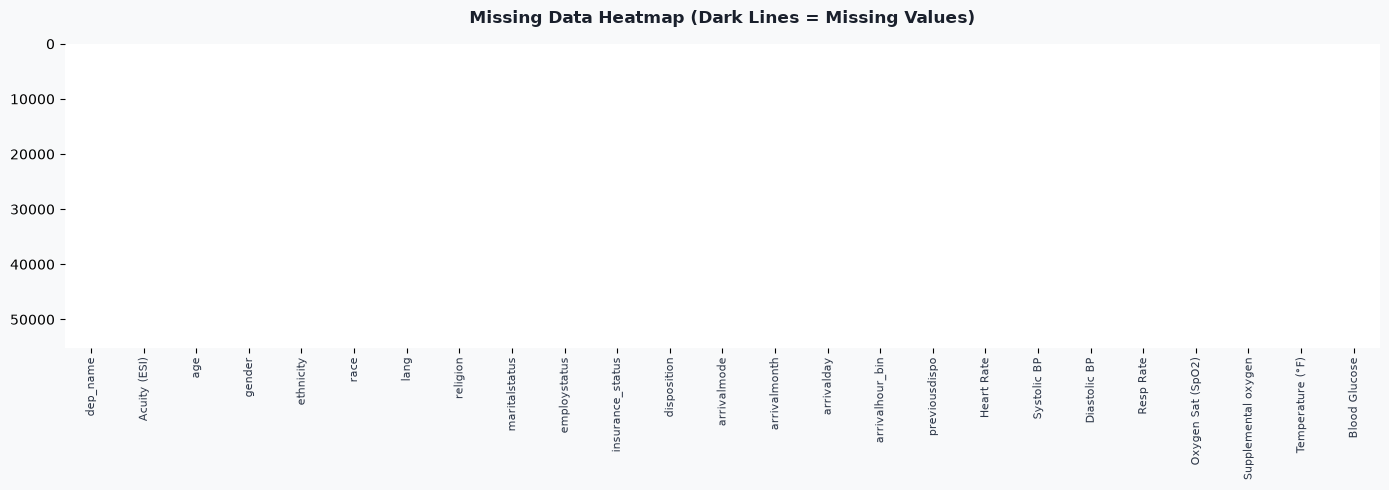

In [25]:
# Missing Data HeatMap

src = (raw if raw is not None else df)
# Strip out chief complaints to keep the chart clean
structured = [c for c in src.columns if not c.startswith("cc_")]

# Create a true/false matrix grid where True = Empty cell
missing_grid = src[structured].isna().values

# Create a single standalone plot window
fig, ax = plt.subplots(figsize=(14, 5), facecolor='#F8F9FA')
ax.set_facecolor('#F8F9FA')

# Paint the matrix grid (black lines show missing cells)
ax.imshow(missing_grid, aspect="auto", cmap="binary", interpolation="none")

# Swap database shortcodes with clean names
ax.set_xticks(range(len(structured)))
ax.set_xticklabels([CLEAN_LABELS.get(c, c) for c in structured], rotation=90, fontsize=8, color="#2D3748")
ax.set_title("Missing Data Heatmap (Dark Lines = Missing Values)", fontsize=12, fontweight="bold", pad=15, color="#1A202C")

# Strip borders off the chart
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("figs/01_missingness_FINAL.png", dpi=110, facecolor=fig.get_facecolor())
plt.show()

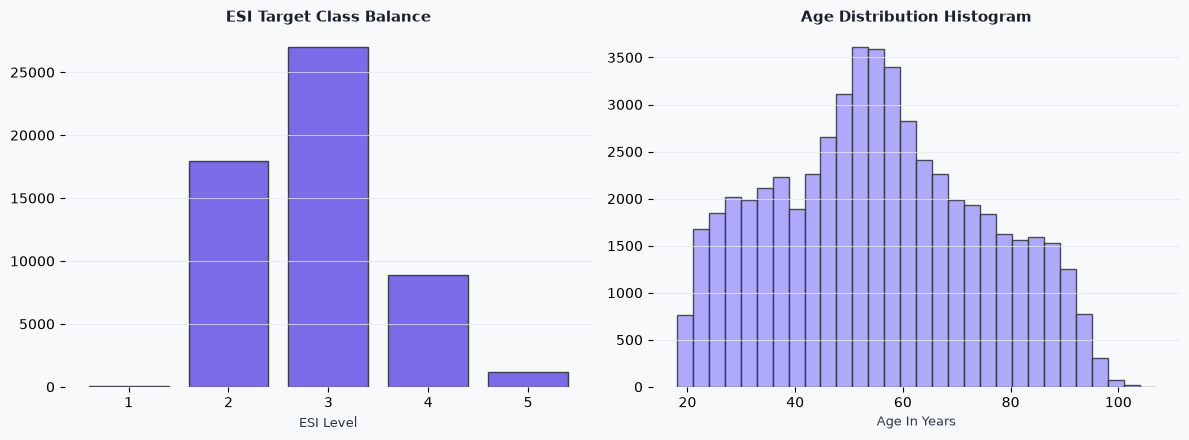

In [29]:
# Target and Age Distributions

# Create a fresh window split into 2 side-by-side plots: ax[0] and ax[1]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), facecolor='#F8F9FA')
for a in ax:
    a.set_facecolor('#F8F9FA')

# Left chart (ax[0]): ESI Category counts
esi_counts = df[TARGET].value_counts().sort_index()
ax[0].bar(esi_counts.index, esi_counts.values, color="#6C5CE7", edgecolor="#2D3436", alpha=0.9)
ax[0].set_title("ESI Target Class Balance", fontsize=11, fontweight="bold", color="#1A202C")
ax[0].set_xlabel("ESI Level", fontsize=9, color="#2D3748")
ax[0].set_xticks(esi_counts.index)
ax[0].grid(axis="y", color="#E2E8F0", alpha=0.7)

# Right chart (ax[1]): Patient age bars
ax[1].hist(df["age"], bins=30, color="#A29BFE", edgecolor="#2D3436", alpha=0.85)
ax[1].set_title("Age Distribution Histogram", fontsize=11, fontweight="bold", color="#1A202C")
ax[1].set_xlabel("Age In Years", fontsize=9, color="#2D3748")
ax[1].grid(axis="y", color="#E2E8F0", alpha=0.7)

# Strip borders off both subplots
for a in ax:
    for spine in ["top", "right", "left", "bottom"]:
        a.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("figs/02_esi_age_FINAL.png", dpi=110, facecolor=fig.get_facecolor())
plt.show()

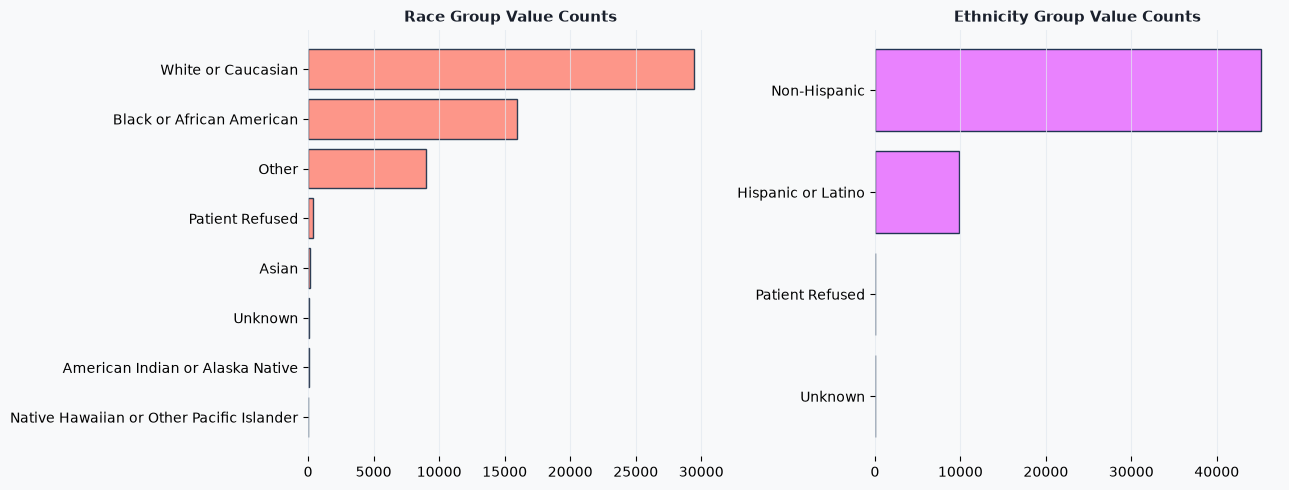

In [31]:
# Demographics

fig, ax = plt.subplots(1, 2, figsize=(13, 5), facecolor='#F8F9FA')
for a in ax:
    a.set_facecolor('#F8F9FA')

# Sort counts from smallest to largest so biggest bar plots at the top
race_counts = df["race"].value_counts().sort_values(ascending=True)
ax[0].barh(race_counts.index, race_counts.values, color="#FF8575", edgecolor="#0A2540", alpha=0.85)
ax[0].set_title("Race Group Value Counts", fontsize=11, fontweight="bold", color="#1A202C")
ax[0].grid(axis="x", color="#E2E8F0", alpha=0.7)

ethnicity_counts = df["ethnicity"].value_counts().sort_values(ascending=True)
ax[1].barh(ethnicity_counts.index, ethnicity_counts.values, color="#E875FF", edgecolor="#0A2540", alpha=0.9)
ax[1].set_title("Ethnicity Group Value Counts", fontsize=11, fontweight="bold", color="#1A202C")
ax[1].grid(axis="x", color="#E2E8F0", alpha=0.7)

for a in ax:
    for spine in ["top", "right", "left", "bottom"]:
        a.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("figs/03_demographics_FINAL.png", dpi=110, facecolor=fig.get_facecolor())
plt.show()

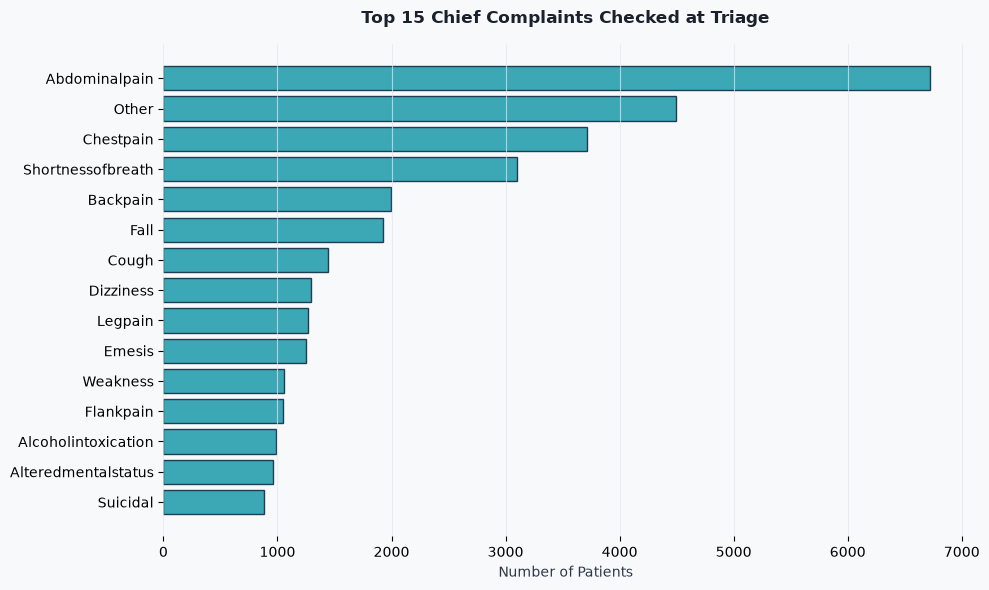

In [32]:
# Cheif Complaints Frequency

# Sum binary columns up to find the most common symptoms
complaint_counts = df[fam["chief_complaints"]].sum()
top15 = complaint_counts.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6), facecolor='#F8F9FA')
ax.set_facecolor('#F8F9FA')

# Drop technical database "cc_" prefixes and capitalize strings beautifully
clean_cc_labels = [c.replace("cc_", "").replace("_", " ").title() for c in top15.index]

ax.barh(clean_cc_labels, top15.values, color="#1B9AAA", edgecolor="#0A2540", alpha=0.85)
ax.set_title("Top 15 Chief Complaints Checked at Triage", fontsize=12, fontweight="bold", pad=15, color="#1A202C")
ax.set_xlabel("Number of Patients", fontsize=10, color="#2D3748")
ax.grid(axis="x", color="#E2E8F0", alpha=0.7)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("figs/04_chief_complaints_FINAL.png", dpi=110, facecolor=fig.get_facecolor())
plt.show()

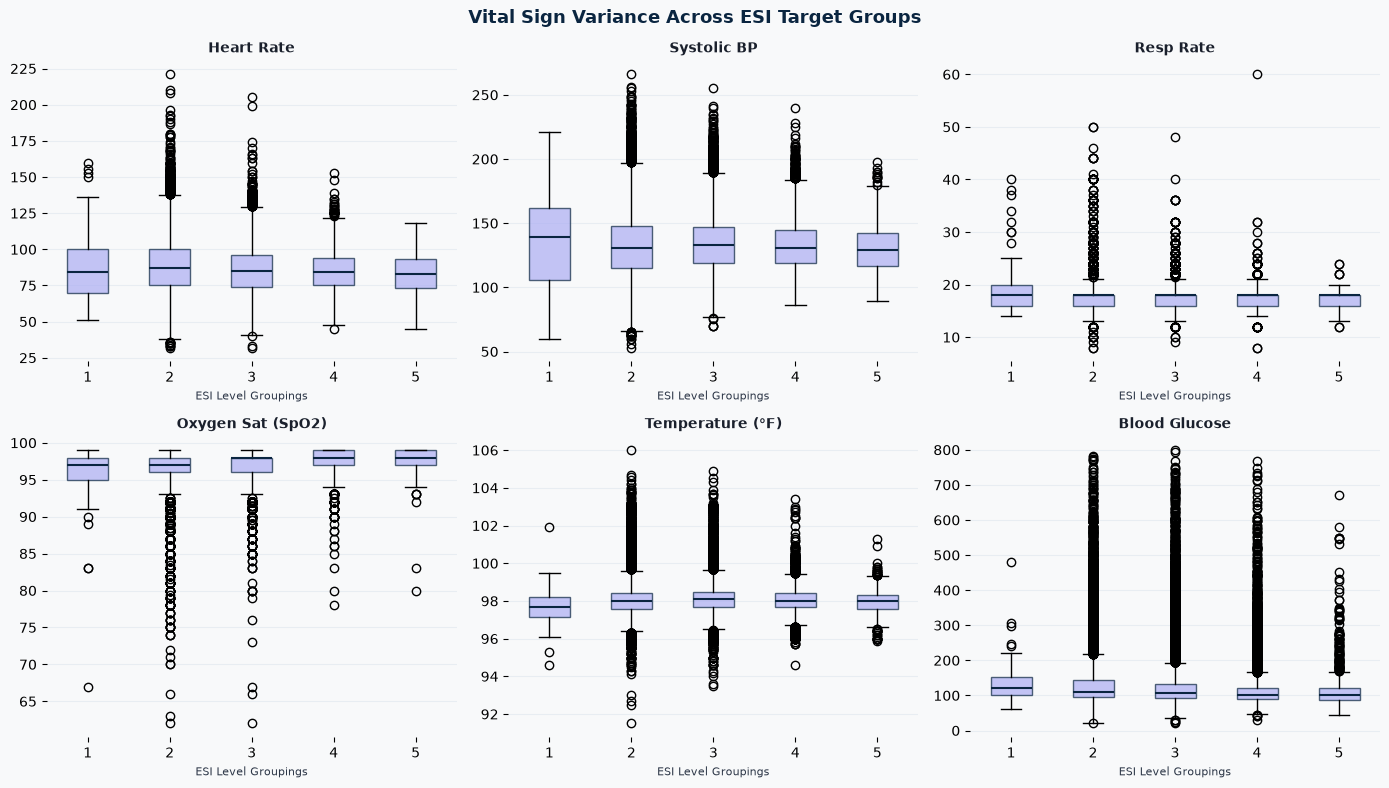

In [38]:
# Boxplot of Vitals by ESI Value

vitals_to_plot = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_rr",
                  "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
esi_levels = sorted(df[TARGET].unique())

# Generate a grid with 2 rows and 3 columns of subplots
fig, axes = plt.subplots(2, 3, figsize=(14, 8), facecolor='#F8F9FA')

# axes.ravel() turns our 2D grid of subplots into a flat list of 6 individual panels
for panel, col in zip(axes.ravel(), vitals_to_plot):
    panel.set_facecolor('#F8F9FA')
    # Filter the vital metric separately for each of the 5 ESI priority levels
    groups = [df.loc[df[TARGET] == level, col] for level in esi_levels]
    
    box = panel.boxplot(groups, tick_labels=esi_levels, patch_artist=True,
                        medianprops=dict(color="#0A2540", linewidth=1.5),
                        boxprops=dict(facecolor="#ACADF2", color="#0A2540", alpha=0.7))
    
    panel.set_title(CLEAN_LABELS.get(col, col), fontsize=10, fontweight="bold", color="#1A202C")
    panel.set_xlabel("ESI Level Groupings", fontsize=8, color="#2D3748")
    panel.grid(axis="y", color="#E2E8F0", alpha=0.7)
    
    for spine in ["top", "right", "left", "bottom"]:
        panel.spines[spine].set_visible(False)

plt.suptitle("Vital Sign Variance Across ESI Target Groups", fontsize=13, fontweight="bold", y=0.98, color="#0A2540")
plt.tight_layout()
plt.savefig("figs/05_vitals_by_esi_FINAL.png", dpi=110, facecolor=fig.get_facecolor())
plt.show()

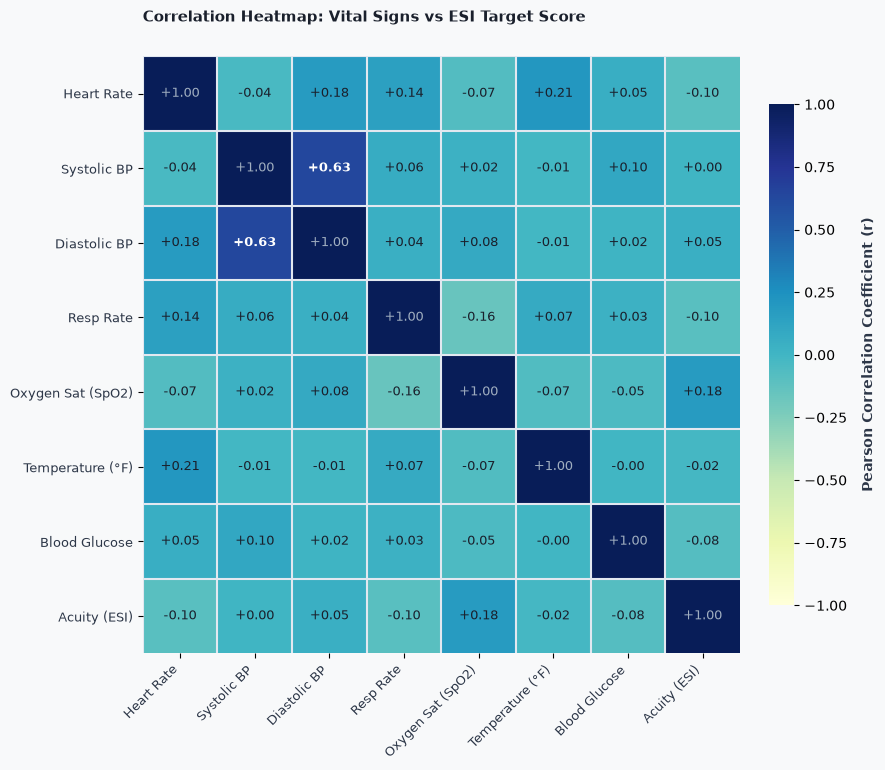

In [39]:
# Correlation Matrix Map

cols = fam["vitals"] + [TARGET]
display_labels = [CLEAN_LABELS.get(c, c) for c in cols]
corr = df[cols].corr()  # Calculates correlation table matrix

fig, ax = plt.subplots(figsize=(9, 8), facecolor='#F8F9FA')
ax.set_facecolor('#F8F9FA')

# Swapped cmap to "YlGnBu" for a premium yellow-green-blue analytics gradient
im = ax.imshow(corr, cmap="YlGnBu", vmin=-1, vmax=1)

ax.set_xticks(range(len(cols)))
ax.set_xticklabels(display_labels, rotation=45, ha="right", fontsize=9, color="#2D3748")
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(display_labels, fontsize=9, color="#2D3748")

# Shift minor grid lines by -0.5 to cleanly draw boxes around individual numbers
ax.set_xticks(np.arange(len(cols)) - 0.5, minor=True)
ax.set_yticks(np.arange(len(cols)) - 0.5, minor=True)
ax.grid(which="minor", color="#E2E8F0", linestyle="-", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

# Overlay correlation value text over the matching square
for i in range(len(cols)):
    for j in range(len(cols)):
        value = corr.iloc[i, j]
        if i == j:
            text_color = "#A0AEC0"  # Gray out diagonal line matching a feature with itself
            font_weight = "normal"
        else:
            # Dynamic contrast check: switch text to white on dark cells, dark text on bright cells
            text_color = "white" if abs(value) > 0.4 else "#1A202C"
            font_weight = "bold" if abs(value) > 0.25 else "normal"
            
        ax.text(j, i, f"{value:+.2f}", ha="center", va="center", 
                fontsize=9, color=text_color, fontweight=font_weight)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

# Add side colorbar scale
cbar = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.04)
cbar.set_label("Pearson Correlation Coefficient (r)", fontsize=10, fontweight="bold", labelpad=10, color="#2D3748")
cbar.outline.set_visible(False)

ax.set_title("Correlation Heatmap: Vital Signs vs ESI Target Score", 
             fontsize=11, fontweight="bold", pad=25, color="#1A202C", loc="left")

plt.tight_layout()
plt.savefig("figs/06_correlation_FINAL.png", dpi=110, facecolor=fig.get_facecolor())
plt.show()